# Fancy Data Visualizations with Matplotlib and Seaborn

**Estimated time:** about 3 hours  
**Goal:** Move beyond basic plots and learn how to create more polished, report-ready visualizations.

In this notebook, we will use the retail visualization dataset and practice:

1. Multiple lines in one plot  
2. Subplots and small multiples  
3. Grouped and stacked bar charts  
4. Heatmaps  
5. Pair plots  
6. Facet grids  
7. Regression plots  
8. Violin and swarm plots  
9. Annotated charts  
10. Final mini visualization report

The focus is not just making charts look “cool,” but making charts that communicate business insights clearly.


## 0. Setup

In [2]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Optional: make plots look cleaner
sns.set_theme(style="whitegrid")

# Show plots inside Jupyter Notebook
%matplotlib inline

In [3]:
# Load the dataset

df = pd.read_csv("retail_visualization_dataset.csv")

# Preview the data
df.head()

,order_id,order_date,region,state,segment,category,sub_category,ship_mode,quantity,discount,sales,profit,customer_id
0,ORD-2024-00000,2024-04-12,South,Georgia,Consumer,Furniture,Furnishings,Second Class,4,0.21,222.00,-32.66,C11733
1,ORD-2025-00001,2025-03-11,Central,Minnesota,Consumer,Furniture,Tables,Standard Class,1,0.29,211.93,-33.74,C10169
2,ORD-2024-00002,2024-09-27,South,North Carolina,Consumer,Office Supplies,Binders,Standard Class,7,0.05,132.78,19.92,C10460
3,ORD-2024-00003,2024-04-16,West,California,Home Office,Office Supplies,Binders,Standard Class,4,0.10,150.06,8.11,C10428
4,ORD-2024-00004,2024-03-12,East,New Jersey,Consumer,Office Supplies,Storage,Second Class,7,0.07,355.65,44.73,C11370


In [4]:
# Check basic information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6014 entries, 0 to 6013
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      6014 non-null   str    
 1   order_date    6014 non-null   str    
 2   region        6014 non-null   str    
 3   state         6014 non-null   str    
 4   segment       6014 non-null   str    
 5   category      6014 non-null   str    
 6   sub_category  6014 non-null   str    
 7   ship_mode     6002 non-null   str    
 8   quantity      6014 non-null   int64  
 9   discount      5996 non-null   float64
 10  sales         6014 non-null   float64
 11  profit        5996 non-null   float64
 12  customer_id   6014 non-null   str    
dtypes: float64(3), int64(1), str(9)
memory usage: 610.9 KB


In [5]:
# Convert order_date to datetime

df["order_date"] = pd.to_datetime(df["order_date"])

# Create a monthly column for time-series analysis
df["order_month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()

# Preview
df[["order_date", "order_month", "sales", "profit", "category", "segment"]].head()

,order_date,order_month,sales,profit,category,segment
0,2024-04-12,2024-04-01,222.00,-32.66,Furniture,Consumer
1,2025-03-11,2025-03-01,211.93,-33.74,Furniture,Consumer
2,2024-09-27,2024-09-01,132.78,19.92,Office Supplies,Consumer
3,2024-04-16,2024-04-01,150.06,8.11,Office Supplies,Home Office
4,2024-03-12,2024-03-01,355.65,44.73,Office Supplies,Consumer


## 1. Multiple Lines in One Plot

A line chart is useful for showing trends over time.  
A multi-line chart lets us compare trends across groups.

**Business question:**  
How does monthly profit change over time for each product category?


In [6]:
# Step 1: Aggregate monthly profit by category

monthly_category_profit = (
    df.groupby(["order_month", "category"])["profit"]
    .sum()
    .reset_index()
)

monthly_category_profit.head()

,order_month,category,profit
0,2024-01-01,Furniture,6.93
1,2024-01-01,Office Supplies,960.05
2,2024-01-01,Technology,12191.12
3,2024-02-01,Furniture,-657.07
4,2024-02-01,Office Supplies,512.49


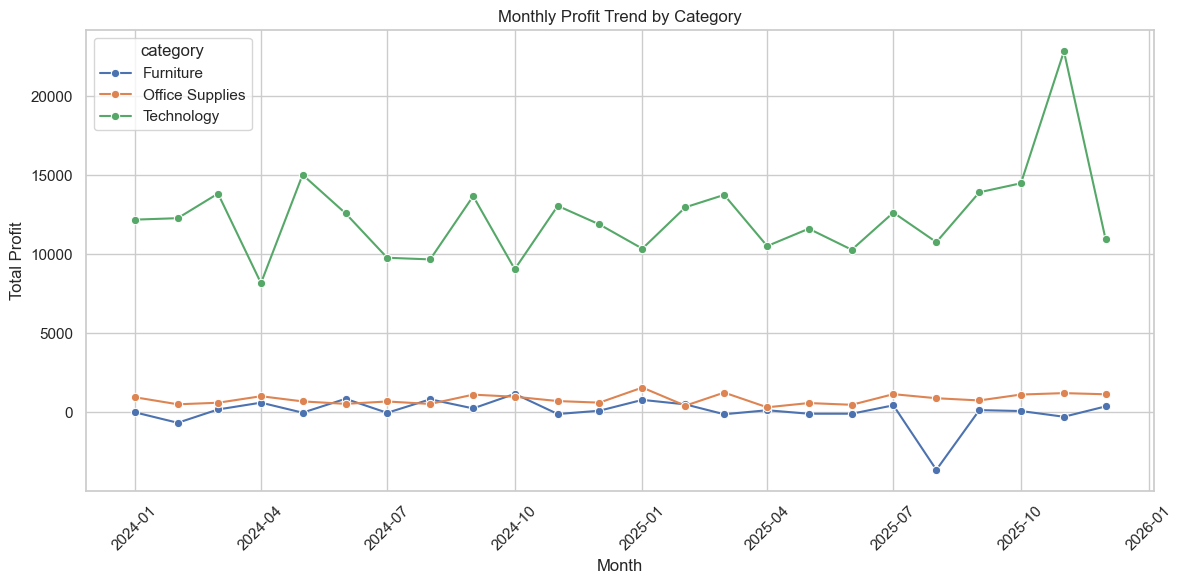

In [7]:
# Step 2: Draw multiple lines using seaborn

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_category_profit,
    x="order_month",
    y="profit",
    hue="category",
    marker="o"
)

plt.title("Monthly Profit Trend by Category")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Teaching Note

The key idea is:

```python
hue="category"
```

This tells seaborn to draw one line for each category.


## 2. Multiple Lines with Matplotlib

Sometimes we want more control. Matplotlib allows us to manually draw each line.


In [8]:
# Create a pivot table: rows = month, columns = category, values = total profit

profit_pivot = monthly_category_profit.pivot(
    index="order_month",
    columns="category",
    values="profit"
)

profit_pivot.head()

category,Furniture,Office Supplies,Technology
order_month,,,
2024-01-01,6.93,960.05,12191.12
2024-02-01,-657.07,512.49,12283.71
2024-03-01,184.89,610.48,13839.37
2024-04-01,616.53,1023.08,8175.69
2024-05-01,-17.09,695.94,15029.96


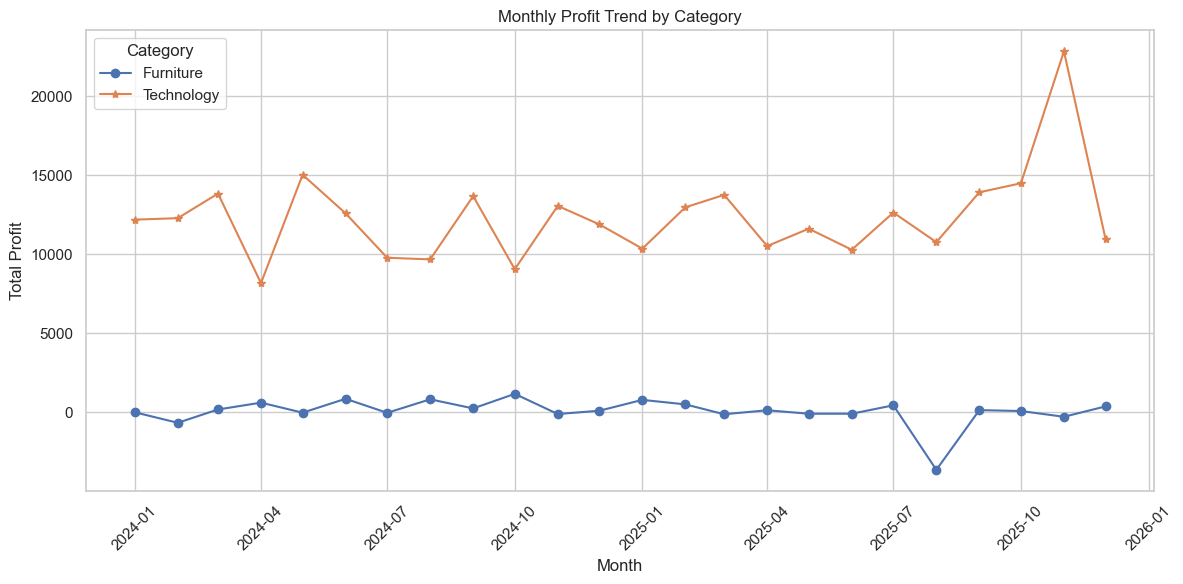

In [11]:
plt.figure(figsize=(12, 6))

# Draw each category as a separate line
# for category in profit_pivot.columns:
#     plt.plot(
#         profit_pivot.index,
#         profit_pivot[category],
#         marker="o",
#         label=category
#     )

plt.plot(profit_pivot.index, profit_pivot["Furniture"], marker="o", label="Furniture")
plt.plot(profit_pivot.index, profit_pivot["Technology"], marker="*", label="Technology")
plt.title("Monthly Profit Trend by Category")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.legend(title="Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Small Multiples with Subplots

Sometimes putting all lines in one chart becomes crowded.  
Small multiples show each group in its own subplot.

**Business question:**  
How does monthly sales trend differ across categories?


In [26]:
# Aggregate monthly sales by category

monthly_category_sales = (
    df.groupby(["order_month", "category"])["sales"]
    .sum()
    .reset_index()
)

monthly_category_sales.head()

,order_month,category,sales
0,2024-01-01,Furniture,49247.23
1,2024-01-01,Office Supplies,20067.70
2,2024-01-01,Technology,79107.75
3,2024-02-01,Furniture,25939.02
4,2024-02-01,Office Supplies,16622.51


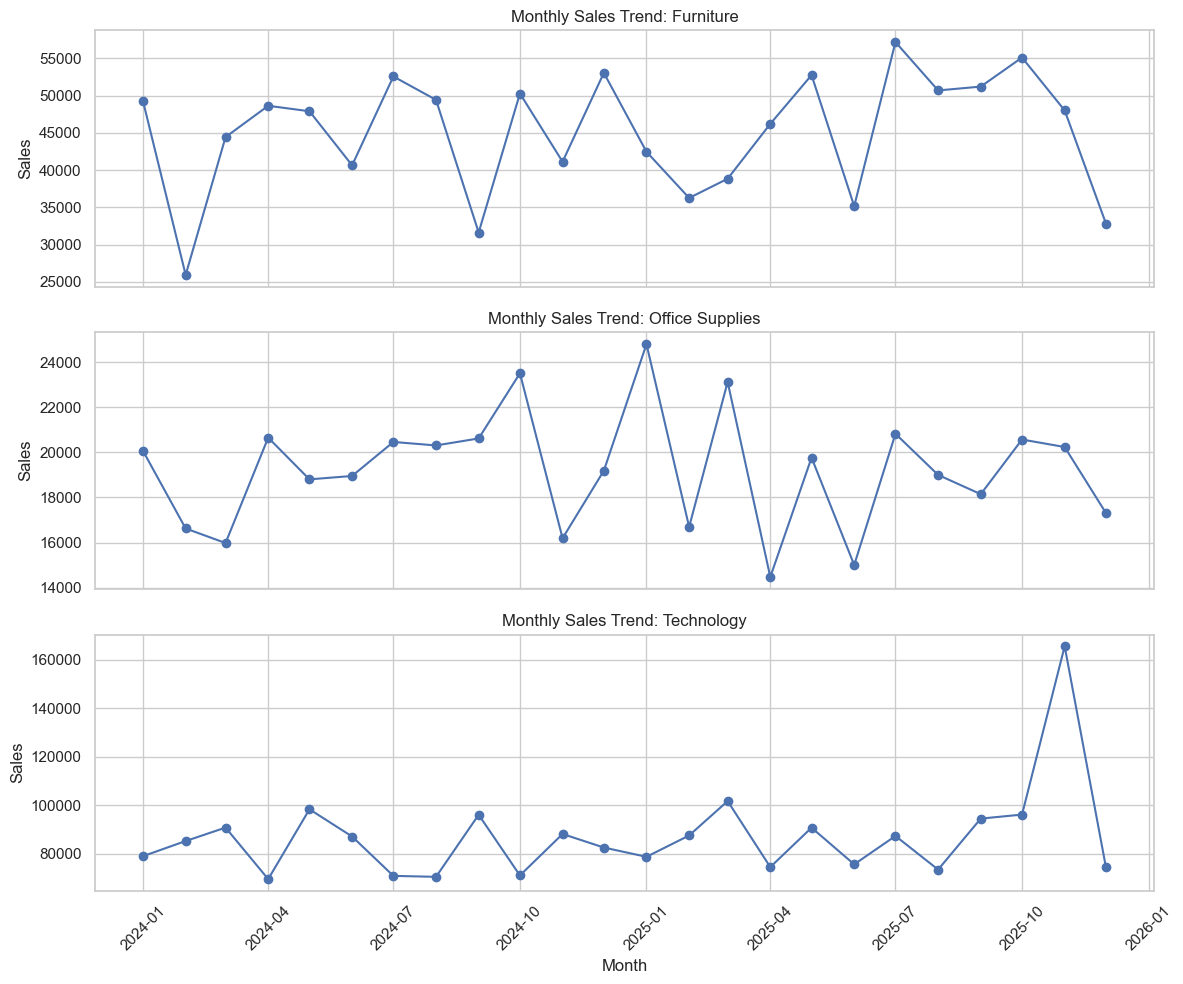

In [ ]:
# Get category names
categories = monthly_category_sales["category"].unique()

# Create one subplot per category
fig, axes = plt.subplots(
    nrows=len(categories),
    ncols=1,
    figsize=(12, 10),
    sharex=True
)

# looping through two lists at the same time.
for ax, category in zip(axes, categories):
    temp = monthly_category_sales[monthly_category_sales["category"] == category]

    ax.plot(temp["order_month"], temp["sales"], marker="o")
    ax.set_title(f"Monthly Sales Trend: {category}")
    ax.set_ylabel("Sales")

axes[-1].set_xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Grouped Bar Chart

Grouped bar charts compare categories across subgroups.

**Business question:**  
What is the average profit for each category and customer segment?


In [28]:
# Aggregate average profit by category and segment

avg_profit = (
    df.groupby(["category", "segment"])["profit"]
    .mean()
    .reset_index()
)

avg_profit.head()

,category,segment,profit
0,Furniture,Consumer,0.302747
1,Furniture,Corporate,0.303216
2,Furniture,Home Office,3.738644
3,Office Supplies,Consumer,8.880121
4,Office Supplies,Corporate,5.660353


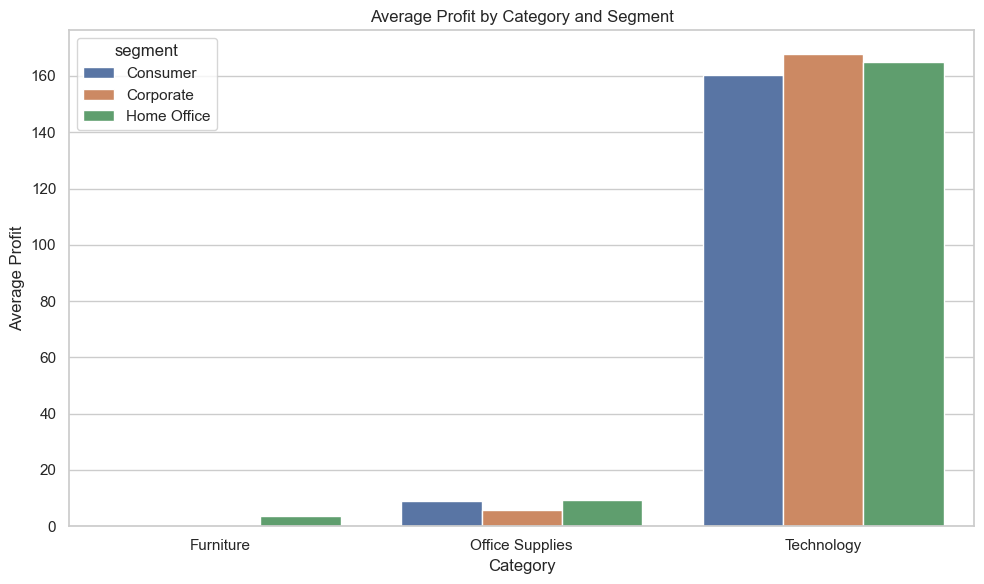

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=avg_profit,
    x="category",
    y="profit",
    hue="segment"
)

plt.title("Average Profit by Category and Segment")
plt.xlabel("Category")
plt.ylabel("Average Profit")
plt.tight_layout()
plt.show()

## 5. Stacked Bar Chart

A stacked bar chart shows both total size and composition.

**Business question:**  
How much sales does each segment contribute within each category?


In [31]:
# Aggregate total sales by category and segment

sales_by_cat_segment = (
    df.groupby(["category", "segment"])["sales"]
    .sum()
    .reset_index()
)
print(sales_by_cat_segment)

# Pivot for stacked bar chart
sales_stack = sales_by_cat_segment.pivot(
    index="category",
    columns="segment",
    values="sales"
)

sales_stack

          category      segment       sales
0        Furniture     Consumer   568448.28
1        Furniture    Corporate   326480.06
2        Furniture  Home Office   186616.00
3  Office Supplies     Consumer   251655.85
4  Office Supplies    Corporate   132153.56
5  Office Supplies  Home Office    77542.41
6       Technology     Consumer  1016224.80
7       Technology    Corporate   681005.06
8       Technology  Home Office   394596.59


segment,Consumer,Corporate,Home Office
category,,,
Furniture,568448.28,326480.06,186616.00
Office Supplies,251655.85,132153.56,77542.41
Technology,1016224.80,681005.06,394596.59


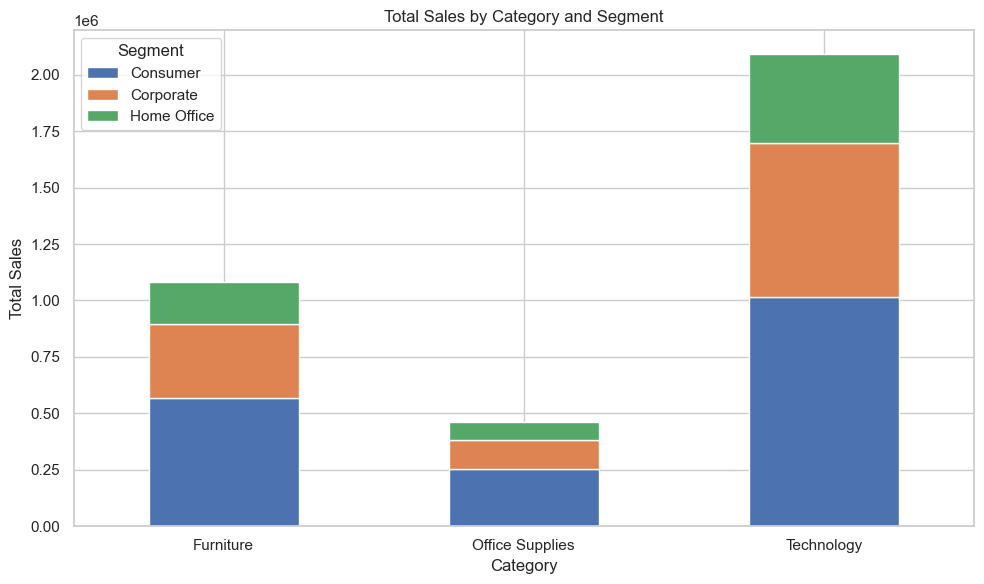

In [17]:
sales_stack.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Total Sales by Category and Segment")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.legend(title="Segment")
plt.tight_layout()
plt.show()

## 6. Heatmap

A heatmap is useful for showing values across two dimensions.

**Business question:**  
Which category-segment combinations generate the highest average profit?


In [18]:
# Create pivot table for heatmap

heatmap_data = df.pivot_table(
    index="category",
    columns="segment",
    values="profit",
    aggfunc="mean"
)

heatmap_data

segment,Consumer,Corporate,Home Office
category,,,
Furniture,0.302747,0.303216,3.738644
Office Supplies,8.880121,5.660353,9.284521
Technology,160.482325,167.795382,165.015925


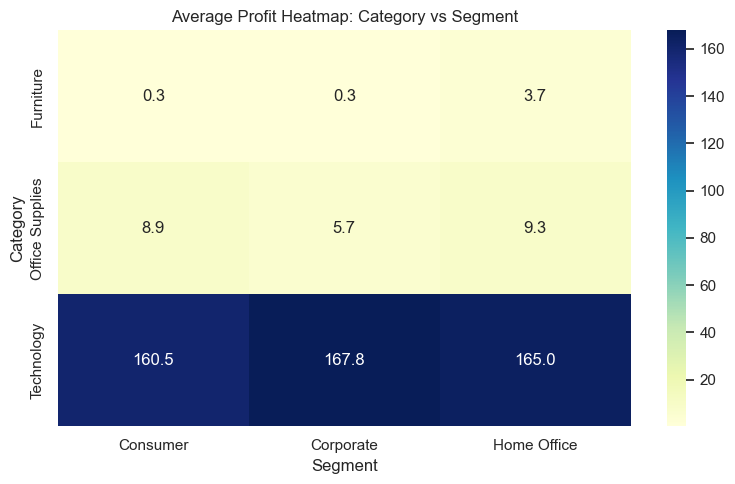

In [32]:
# Create a new figure with custom width and height
plt.figure(figsize=(8, 5))

# Create heatmap
sns.heatmap(
    heatmap_data,     # Input data (pivot table or matrix)
    annot=True,       # Show numerical values inside each cell
    fmt=".1f",        # Format numbers to 1 decimal place
    cmap="YlGnBu"     # Color palette:
                      # Yellow -> Green -> Blue
                      # Different colors represent different value levels
)

# Add chart title
plt.title("Average Profit Heatmap: Category vs Segment")
# Label x-axis
plt.xlabel("Segment")
# Label y-axis
plt.ylabel("Category")
# Automatically adjust spacing/layout
plt.tight_layout()
# Display the chart
plt.show()

## 7. Correlation Heatmap

Correlation heatmaps help us understand relationships among numerical variables.

**Business question:**  
Which numerical variables move together?


In [33]:
# Select numerical columns

numeric_cols = ["sales", "profit", "discount", "quantity"]

corr = df[numeric_cols].corr()

corr

,sales,profit,discount,quantity
sales,1.000000,0.810423,-0.073692,0.418829
profit,0.810423,1.000000,-0.385330,0.262720
discount,-0.073692,-0.385330,1.000000,0.002964
quantity,0.418829,0.262720,0.002964,1.000000


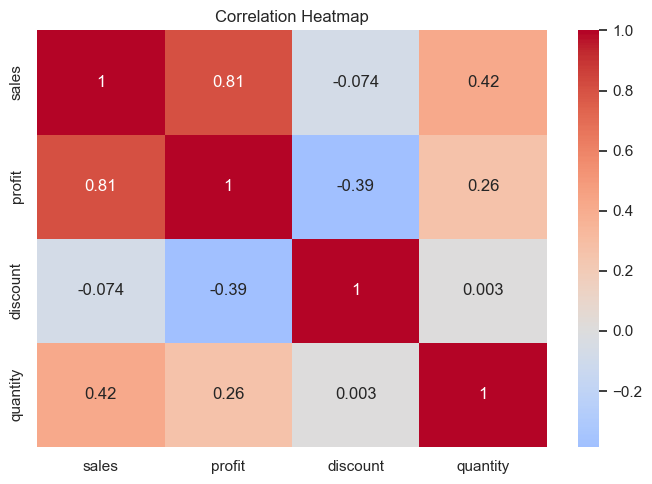

In [34]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 8. Scatterplot with Size and Color

Scatterplots can show more than two variables.

**Business question:**  
How are sales, profit, discount, and category related?


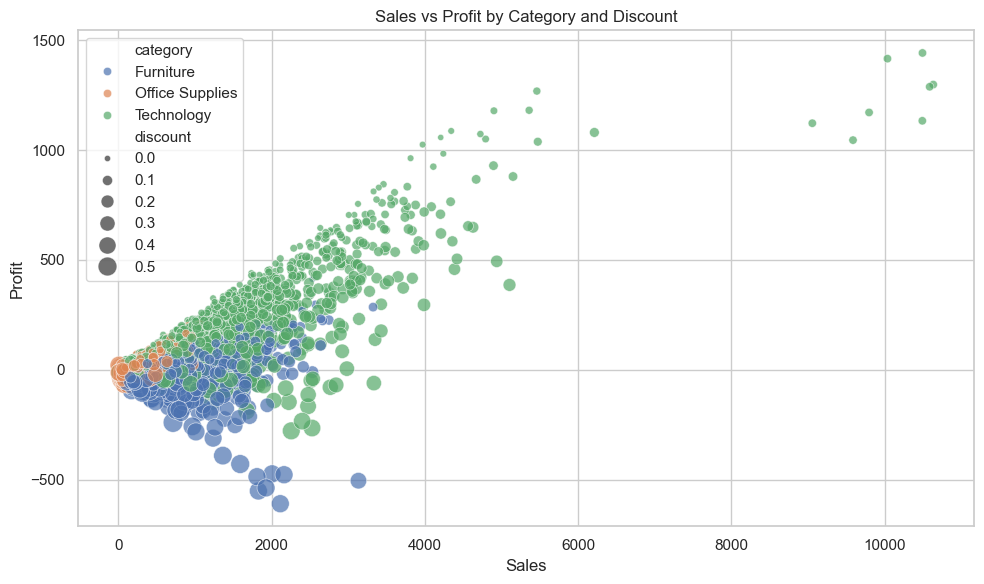

In [35]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="sales",
    y="profit",
    hue="category",
    size="discount",
    sizes=(20, 200),
    alpha=0.7
)

plt.title("Sales vs Profit by Category and Discount")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

### Interpretation Reminder

- X-axis: sales  
- Y-axis: profit  
- Color: category  
- Dot size: discount  

This allows us to see whether high-discount orders are associated with lower profit.


## 9. Regression Plot

A regression plot adds a trend line to a scatterplot.

**Business question:**  
Is there a general relationship between sales and profit?


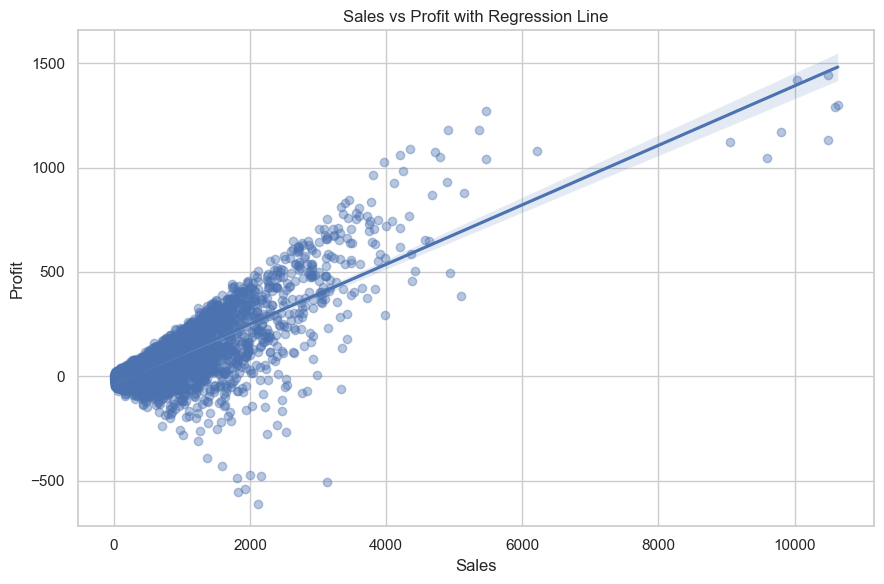

In [36]:
# Create a new figure with custom size
plt.figure(figsize=(9, 6))
# Create regression plot
sns.regplot(
    data=df,          # Dataset
    x="sales",        # Variable for x-axis
    y="profit",       # Variable for y-axis
    # Additional settings for scatter points
    scatter_kws={
        "alpha": 0.4  # Transparency level for points
                       # Helps reduce overplotting when many points overlap
    }
)

# Add chart title
plt.title("Sales vs Profit with Regression Line")
# Label x-axis
plt.xlabel("Sales")
# Label y-axis
plt.ylabel("Profit")
# Automatically adjust layout and spacing
plt.tight_layout()
# Display chart
plt.show()

## 10. Regression by Category

We can use `lmplot()` to compare regression relationships across groups.


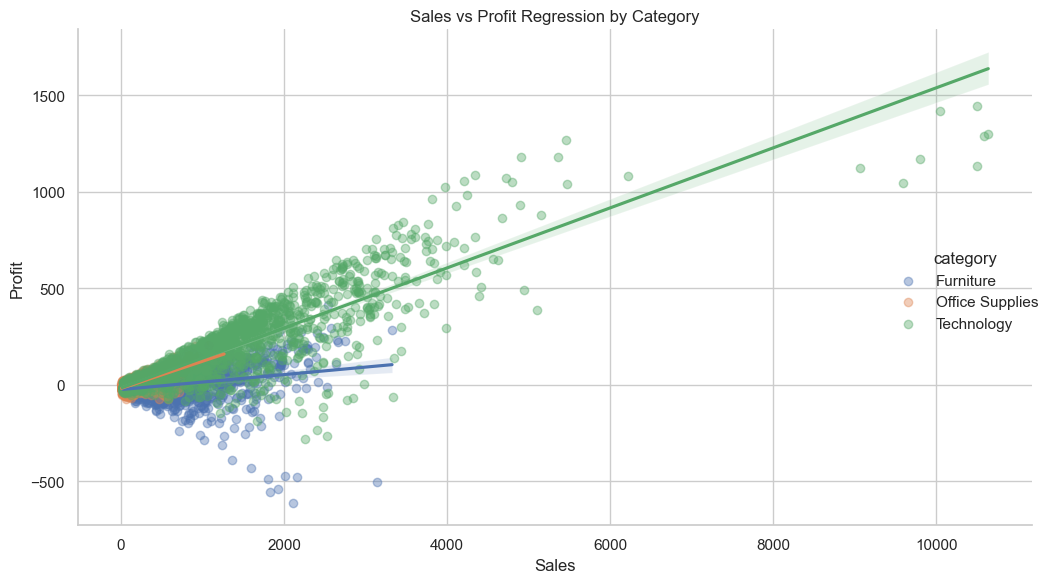

In [37]:
# Create regression plot with separate regression lines by category
sns.lmplot(
    
    data=df,          # Dataset
    x="sales",        # Variable for x-axis
    y="profit",       # Variable for y-axis
    hue="category",   # Create separate colors and regression lines
                      # for each product category
    height=6,         # Height of the figure
    aspect=1.5,       # Width-to-height ratio
                      # Final width = height × aspect
    # Additional settings for scatter points
    scatter_kws={
        "alpha": 0.4  # Make points semi-transparent
                      # Helps reduce overlap in dense areas
    }
)

plt.title("Sales vs Profit Regression by Category")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

## 11. FacetGrid: One Plot Per Category

FacetGrid creates multiple plots based on a grouping variable.

**Business question:**  
Do sales distributions look different across categories?


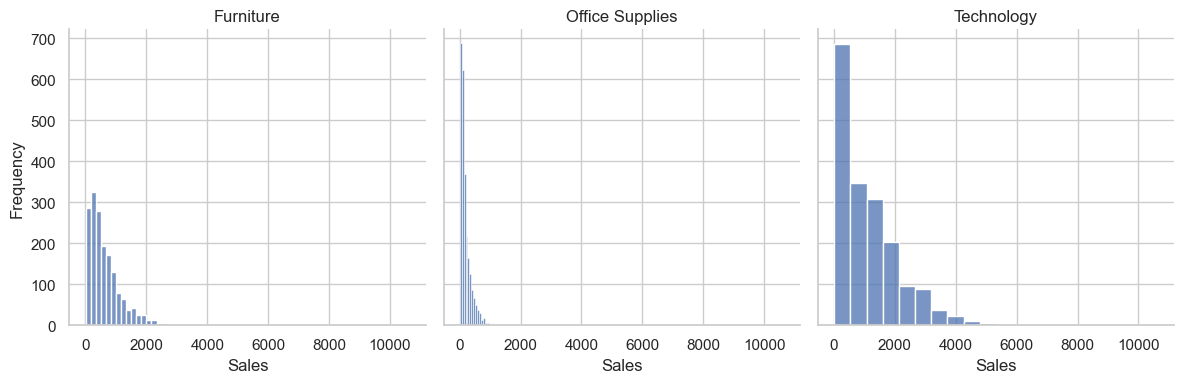

In [38]:
# Create FacetGrid object
# FacetGrid creates multiple subplots based on a grouping variable

g = sns.FacetGrid(
    df,                # Dataset
    col="category",    # Create one subplot for each category
    height=4,          # Height of each subplot
    aspect=1           # Width-to-height ratio
)

# Map a plotting function onto each subplot
g.map_dataframe(
    sns.histplot,      # Plotting function to use
    x="sales",         # Variable for x-axis
    bins=20            # Number of histogram bins
)

# Set subplot titles
# {col_name} automatically inserts category name
g.set_titles("{col_name}")

# Set common axis labels for all subplots
g.set_axis_labels("Sales", "Frequency")

# Display the chart
plt.show()

## 12. Violin Plot

A violin plot shows distribution shape, not just quartiles.

**Business question:**  
How does profit distribution differ by category?


In [40]:
df.head(1)

,order_id,order_date,region,state,segment,category,sub_category,ship_mode,quantity,discount,sales,profit,customer_id,order_month
0,ORD-2024-00000,2024-04-12,South,Georgia,Consumer,Furniture,Furnishings,Second Class,4,0.21,222.0,-32.66,C11733,2024-04-01


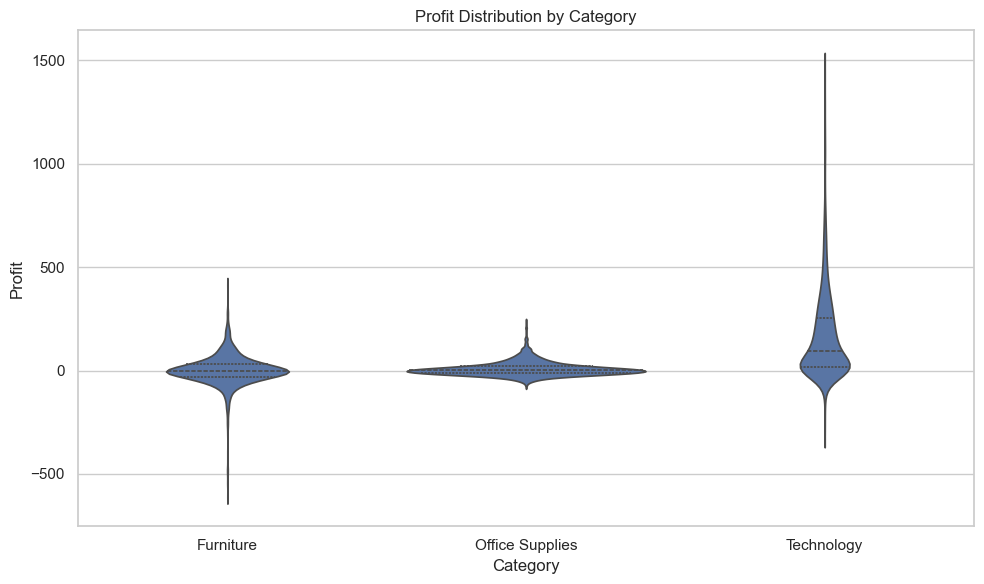

In [39]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="category",
    y="profit",
    inner="quartile"
)

plt.title("Profit Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

## 13. Boxplot + Swarmplot

A boxplot summarizes the distribution.  
A swarmplot shows individual data points.

This combination can be powerful but may be slow for large datasets.


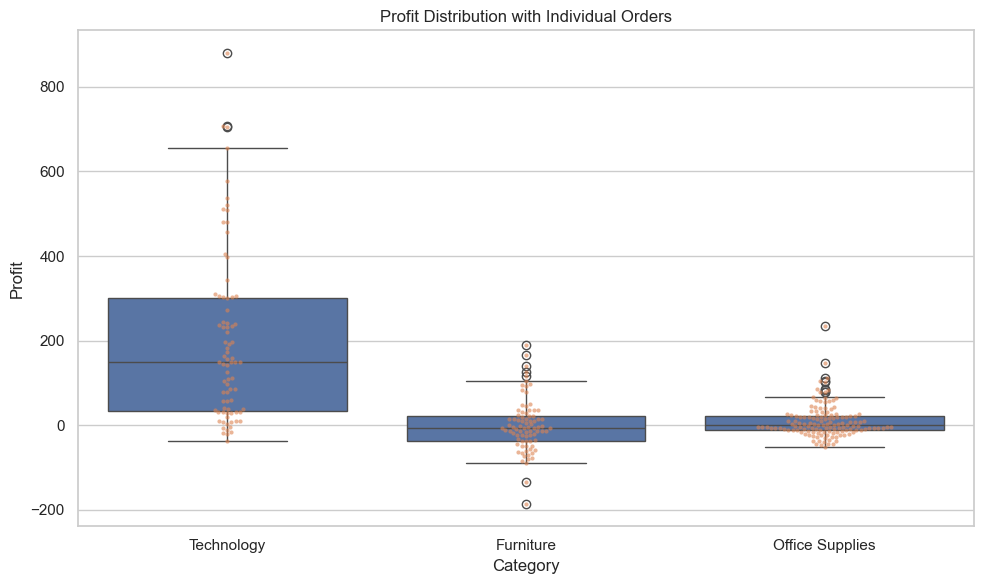

In [41]:
# To keep the swarmplot readable, sample the data

sample_df = df.sample(n=min(300, len(df)), random_state=42)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=sample_df,
    x="category",
    y="profit"
)

sns.swarmplot(
    data=sample_df,
    x="category",
    y="profit",
    size=3,
    alpha=0.6
)

plt.title("Profit Distribution with Individual Orders")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

## 14. Pair Plot

A pair plot shows relationships among multiple numerical variables.

Useful for quick exploratory data analysis.


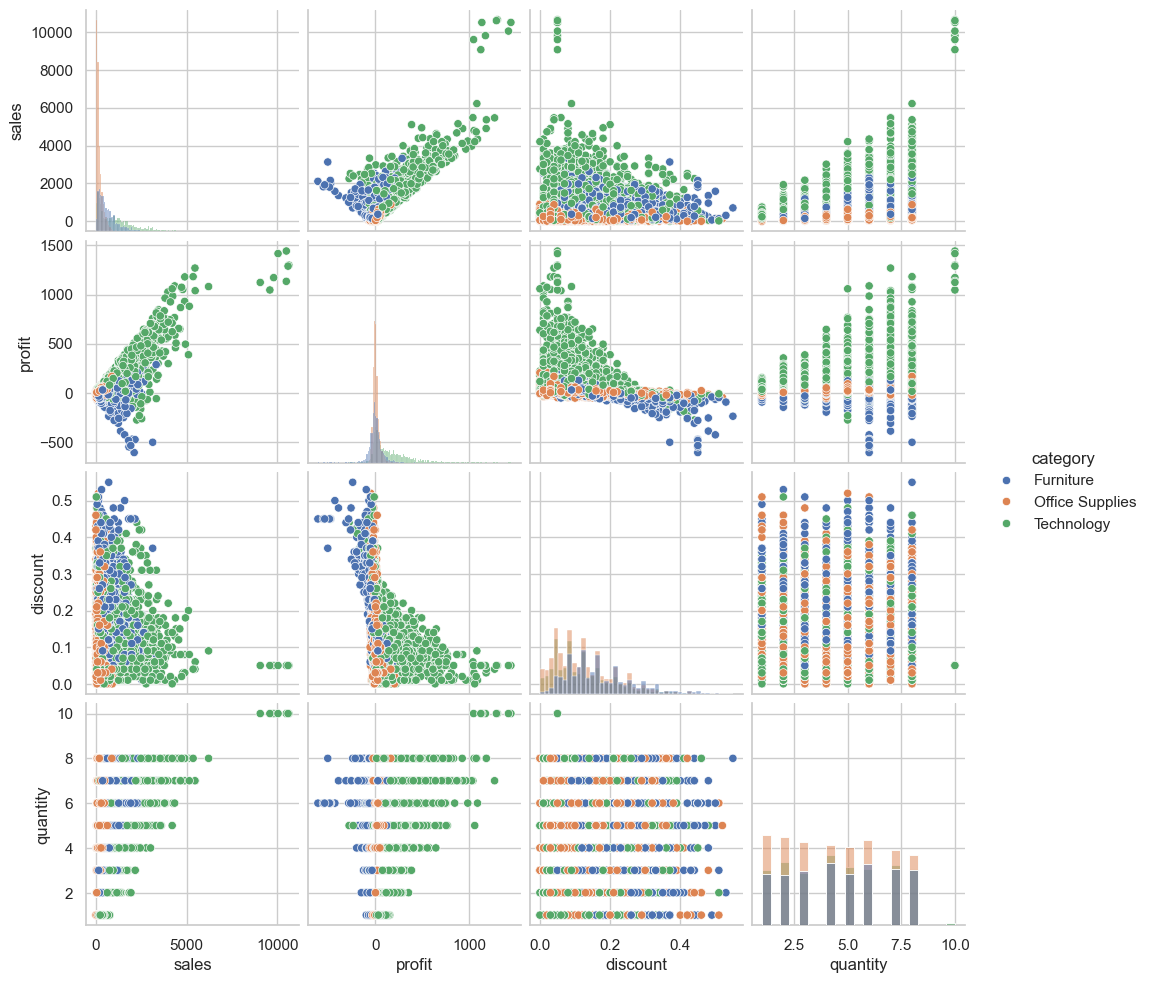

In [42]:
sns.pairplot(
    df[["sales", "profit", "discount", "quantity", "category"]],
    hue="category",
    diag_kind="hist"
)

plt.show()

## 15. Annotated Bar Chart

Annotation helps make charts more report-ready.

**Business question:**  
Which category has the highest total profit?


In [43]:
category_profit = (
    df.groupby("category")["profit"]
    .sum()
    .reset_index()
    .sort_values("profit", ascending=False)
)

category_profit

,category,profit
2,Technology,296384.78
1,Office Supplies,19960.06
0,Furniture,1525.17


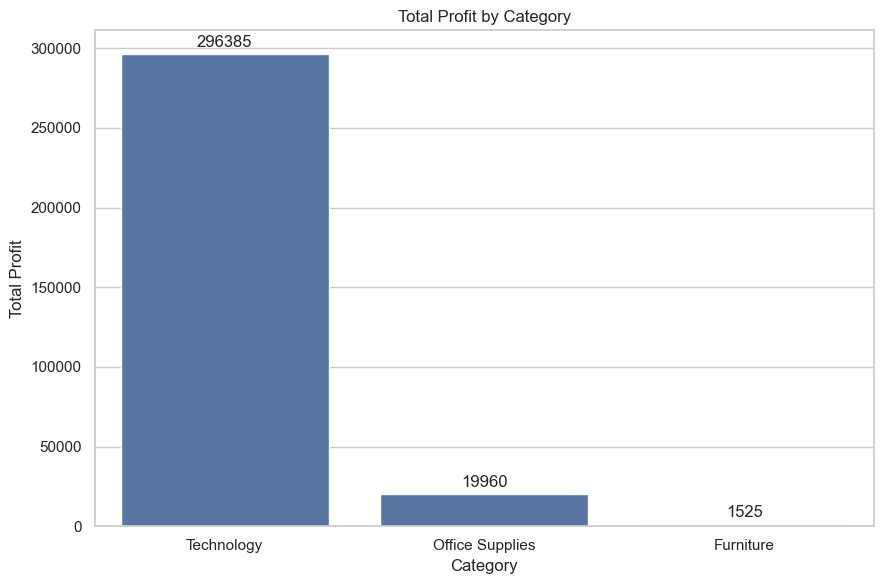

In [44]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=category_profit,
    x="category",
    y="profit"
)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

## 16. Highlighting a Key Point

Sometimes we want to highlight the most important category or month.


In [48]:
# Group data by month and calculate total profit for each month

monthly_total_profit = (
    # Group rows based on order_month
    df.groupby("order_month")["profit"]
    # Calculate total profit for each month
    .sum()
    # Convert grouped result back into a normal DataFrame
    .reset_index()
)

# Find the row with the highest total profit
best_month_row = (
    # Use .loc[] to select a specific row
    monthly_total_profit.loc[
        # idxmax() returns the index position
        # of the maximum profit value
        monthly_total_profit["profit"].idxmax()
    ]
)
# Display the best month row
best_month_row

order_month    2025-11-01 00:00:00
profit                    23778.81
Name: 22, dtype: object

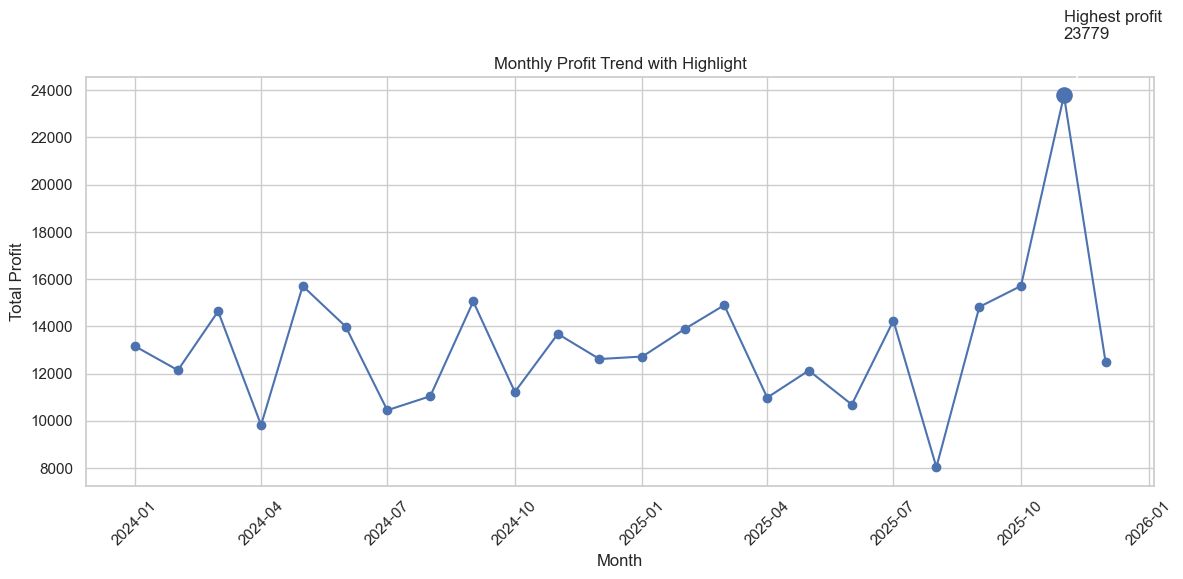

In [47]:
# Create a new figure with custom size
plt.figure(figsize=(12, 6))
# Create line chart for monthly profit trend
plt.plot(  
    monthly_total_profit["order_month"],   # X-axis: month
    monthly_total_profit["profit"],        # Y-axis: total profit
    marker="o"                             # Add circular markers on each point
)

# Highlight the best (highest-profit) month using a scatter point
plt.scatter(
    best_month_row["order_month"],         # X-coordinate of best month
    best_month_row["profit"],              # Y-coordinate of best month
    s=120,                                 # Marker size
    zorder=5                               # Bring point to front layer
)

# Add annotation (text + arrow) to highlight the best month
plt.annotate(
    # Text to display
    f"Highest profit\n{best_month_row['profit']:.0f}",
    # Location of the point being annotated
    xy=(
        best_month_row["order_month"],
        best_month_row["profit"]
    ),
    # Location of the annotation text
    xytext=(
        best_month_row["order_month"],
        best_month_row["profit"] * 1.1
    ),
    # Arrow style
    arrowprops=dict(arrowstyle="->")
)

# Add chart title
plt.title("Monthly Profit Trend with Highlight")
# Label x-axis
plt.xlabel("Month")
# Label y-axis
plt.ylabel("Total Profit")
# Rotate x-axis labels for readability
plt.xticks(rotation=45)
# Automatically adjust spacing/layout
plt.tight_layout()
# Display chart
plt.show()

## 17. Dashboard-Style Figure with Multiple Charts

A data science report often includes several charts together.

Here we create a 2x2 dashboard.


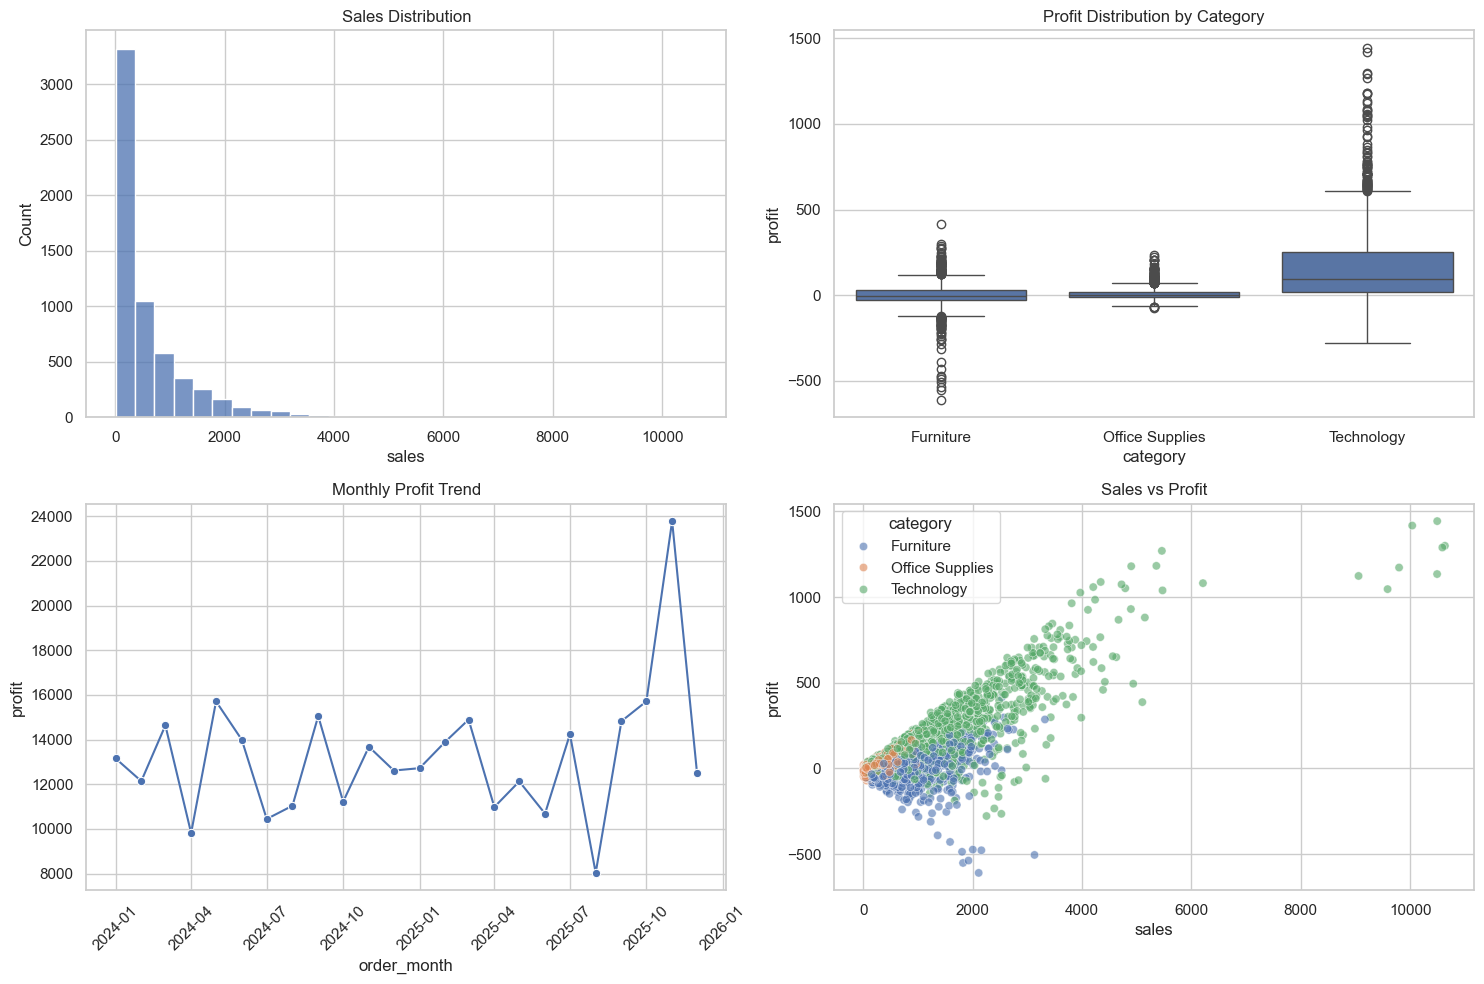

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Chart 1: Sales histogram
sns.histplot(data=df, x="sales", bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Sales Distribution")

# Chart 2: Profit by category
sns.boxplot(data=df, x="category", y="profit", ax=axes[0, 1])
axes[0, 1].set_title("Profit Distribution by Category")

# Chart 3: Monthly profit
sns.lineplot(data=monthly_total_profit, x="order_month", y="profit", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Monthly Profit Trend")
axes[1, 0].tick_params(axis="x", rotation=45)

# Chart 4: Sales vs profit
sns.scatterplot(data=df, x="sales", y="profit", hue="category", alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title("Sales vs Profit")

plt.tight_layout()
plt.show()

## 18. Practice Exercises

Try these exercises in class.

### Exercise 1
Create a multi-line chart showing monthly **sales** by **segment**.

### Exercise 2
Create a heatmap showing average **discount** by **category** and **segment**.

### Exercise 3
Create a scatterplot of **discount** vs **profit**, colored by **category**.

### Exercise 4
Create a dashboard with three charts:
1. Sales histogram  
2. Profit by category boxplot  
3. Monthly sales trend  

### Exercise 5
Find the month with the lowest profit and annotate it on a line chart.


## 19. Suggested Solutions

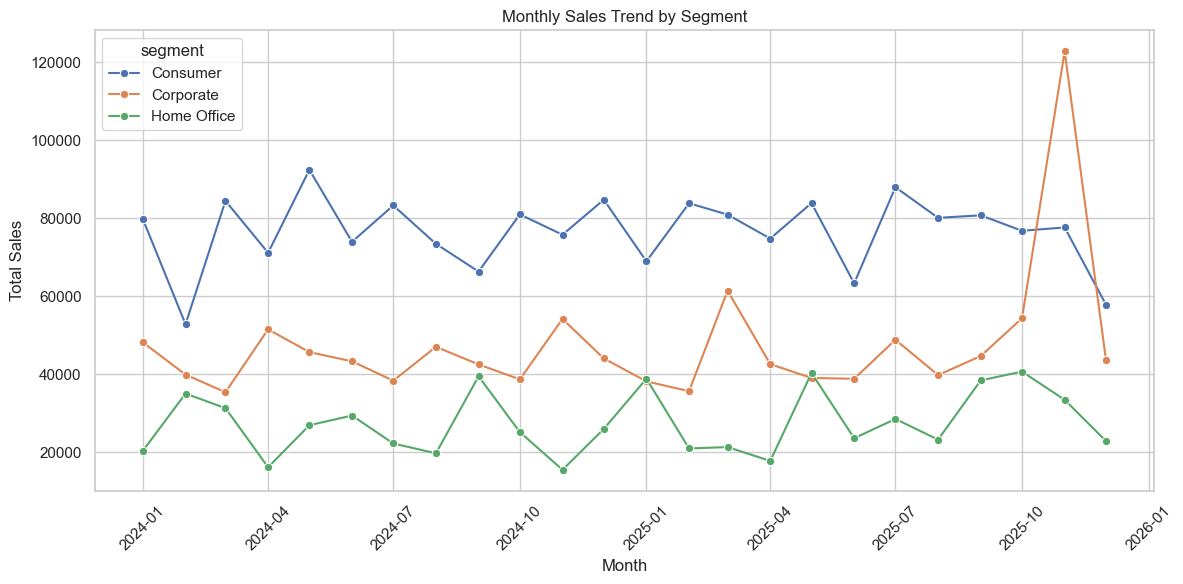

In [50]:
# Exercise 1: Monthly sales by segment

monthly_segment_sales = (
    df.groupby(["order_month", "segment"])["sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_segment_sales,
    x="order_month",
    y="sales",
    hue="segment",
    marker="o"
)

plt.title("Monthly Sales Trend by Segment")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

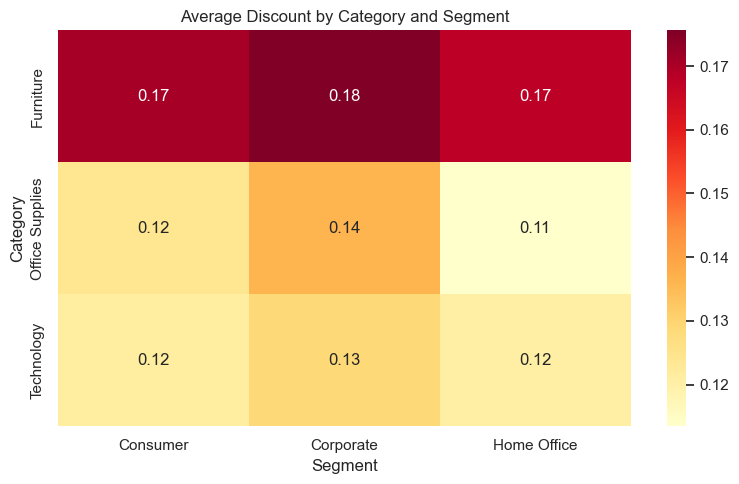

In [51]:
# Exercise 2: Average discount heatmap

discount_heatmap = df.pivot_table(
    index="category",
    columns="segment",
    values="discount",
    aggfunc="mean"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    discount_heatmap,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)

plt.title("Average Discount by Category and Segment")
plt.xlabel("Segment")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

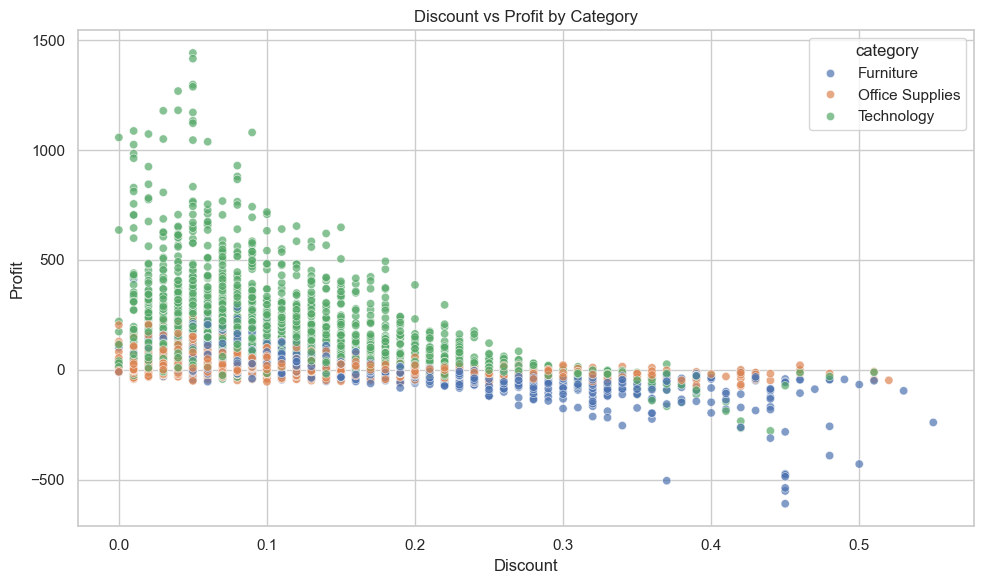

In [52]:
# Exercise 3: Discount vs profit

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="discount",
    y="profit",
    hue="category",
    alpha=0.7
)

plt.title("Discount vs Profit by Category")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

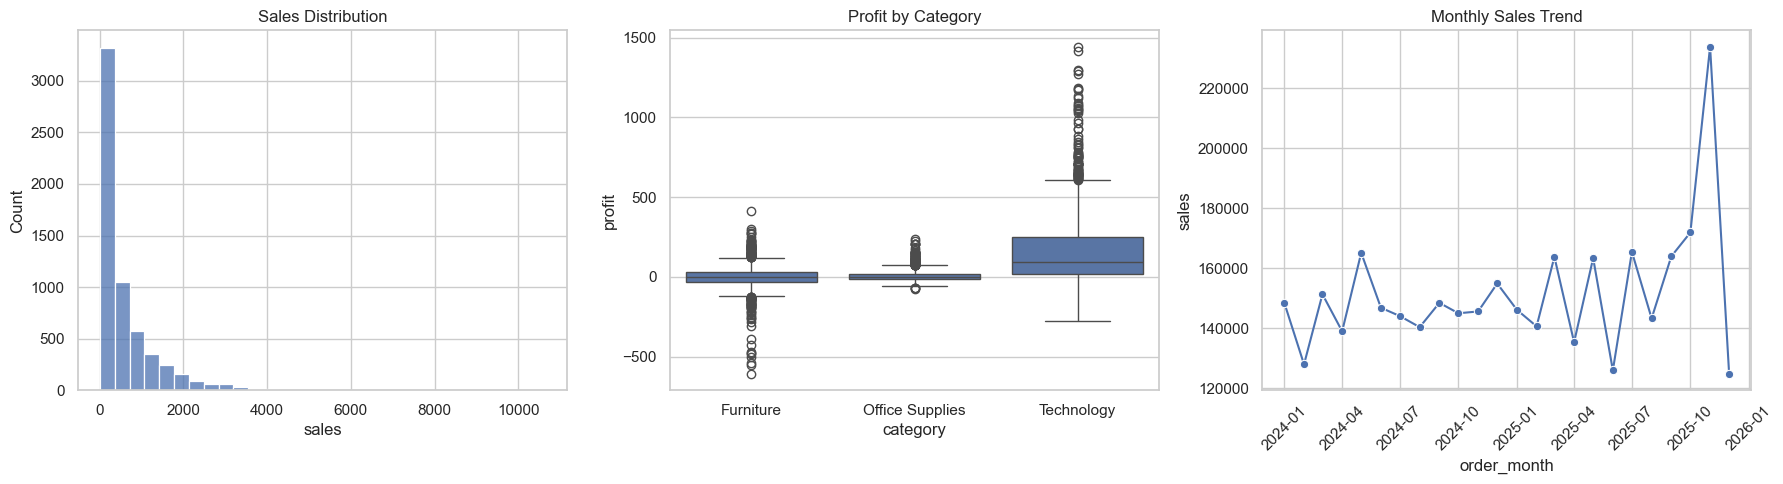

In [53]:
# Exercise 4: Simple dashboard

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x="sales", bins=30, ax=axes[0])
axes[0].set_title("Sales Distribution")

sns.boxplot(data=df, x="category", y="profit", ax=axes[1])
axes[1].set_title("Profit by Category")

monthly_sales = (
    df.groupby("order_month")["sales"]
    .sum()
    .reset_index()
)

sns.lineplot(data=monthly_sales, x="order_month", y="sales", marker="o", ax=axes[2])
axes[2].set_title("Monthly Sales Trend")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

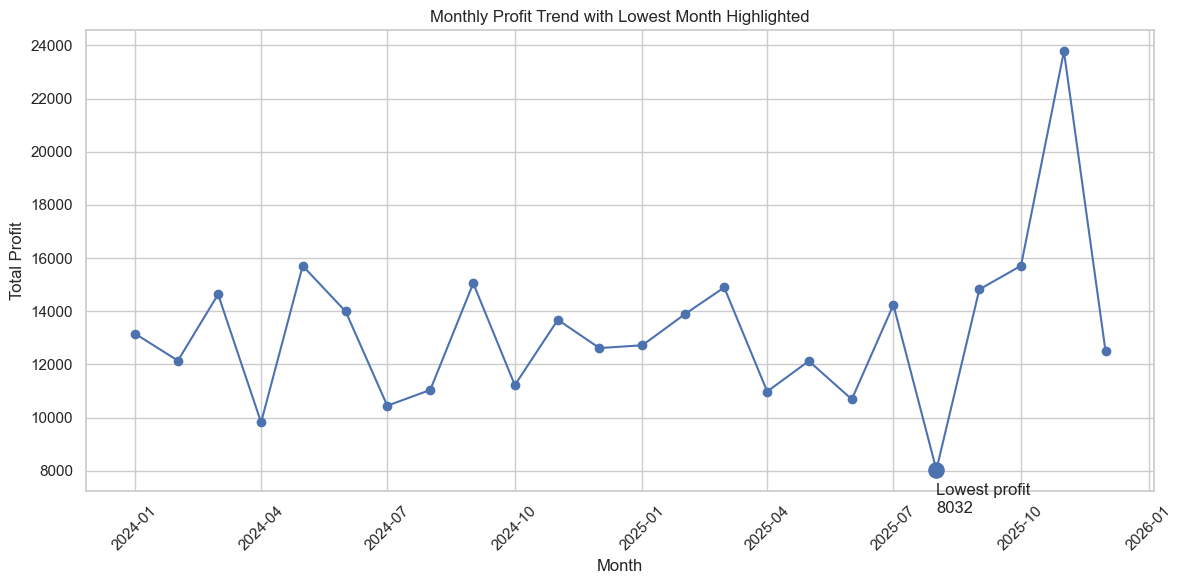

In [54]:
# Exercise 5: Annotate lowest profit month

lowest_month_row = monthly_total_profit.loc[monthly_total_profit["profit"].idxmin()]

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_total_profit["order_month"],
    monthly_total_profit["profit"],
    marker="o"
)

plt.scatter(
    lowest_month_row["order_month"],
    lowest_month_row["profit"],
    s=120,
    zorder=5
)

plt.annotate(
    f"Lowest profit\n{lowest_month_row['profit']:.0f}",
    xy=(lowest_month_row["order_month"], lowest_month_row["profit"]),
    xytext=(lowest_month_row["order_month"], lowest_month_row["profit"] * 0.8),
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly Profit Trend with Lowest Month Highlighted")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 20. Final Mini Report Activity

Ask students to choose **three visualizations** from this notebook and write a short business interpretation.

For each chart, answer:

1. What does the chart show?  
2. What pattern or outlier do you notice?  
3. What business action or follow-up question does it suggest?

Example:

> Technology products generate the strongest profit growth, while Furniture shows more negative-profit outliers. The business should investigate whether Furniture losses are caused by discounting, shipping costs, or product returns.
